In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("All imports successful ✓")

All imports successful ✓


In [3]:
columns = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
           'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']

df = pd.read_csv('magic04.data', header=None, names=columns)
print("Shape:", df.shape)
df.head()

Shape: (19020, 11)


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [4]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== Class Distribution ===")
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True).round(3))

=== Data Types ===
fLength     float64
fWidth      float64
fSize       float64
fConc       float64
fConc1      float64
fAsym       float64
fM3Long     float64
fM3Trans    float64
fAlpha      float64
fDist       float64
class        object
dtype: object

=== Missing Values ===
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64

=== Duplicates ===
Duplicate rows: 115

=== Class Distribution ===
class
g    12332
h     6688
Name: count, dtype: int64
class
g    0.648
h    0.352
Name: proportion, dtype: float64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fLength,19020.0,53.250154,42.364855,4.2835,24.336000,37.14770,70.122175,334.1770
fWidth,19020.0,22.180966,18.346056,0.0000,11.863800,17.13990,24.739475,256.3820
fSize,19020.0,2.825017,0.472599,1.9413,2.477100,2.73960,3.101600,5.3233
fConc,19020.0,0.380327,0.182813,0.0131,0.235800,0.35415,0.503700,0.8930
fConc1,19020.0,0.214657,0.110511,0.0003,0.128475,0.19650,0.285225,0.6752
fAsym,19020.0,-4.331745,59.206062,-457.9161,-20.586550,4.01305,24.063700,575.2407
fM3Long,19020.0,10.545545,51.000118,-331.7800,-12.842775,15.31410,35.837800,238.3210
fM3Trans,19020.0,0.249726,20.827439,-205.8947,-10.849375,0.66620,10.946425,179.8510
fAlpha,19020.0,27.645707,26.103621,0.0000,5.547925,17.67950,45.883550,90.0000
fDist,19020.0,193.818026,74.731787,1.2826,142.492250,191.85145,240.563825,495.5610


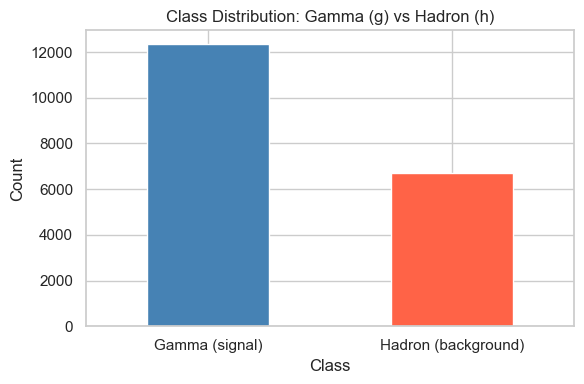

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
df['class'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Class Distribution: Gamma (g) vs Hadron (h)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['Gamma (signal)', 'Hadron (background)'], rotation=0)
plt.tight_layout()
plt.show()

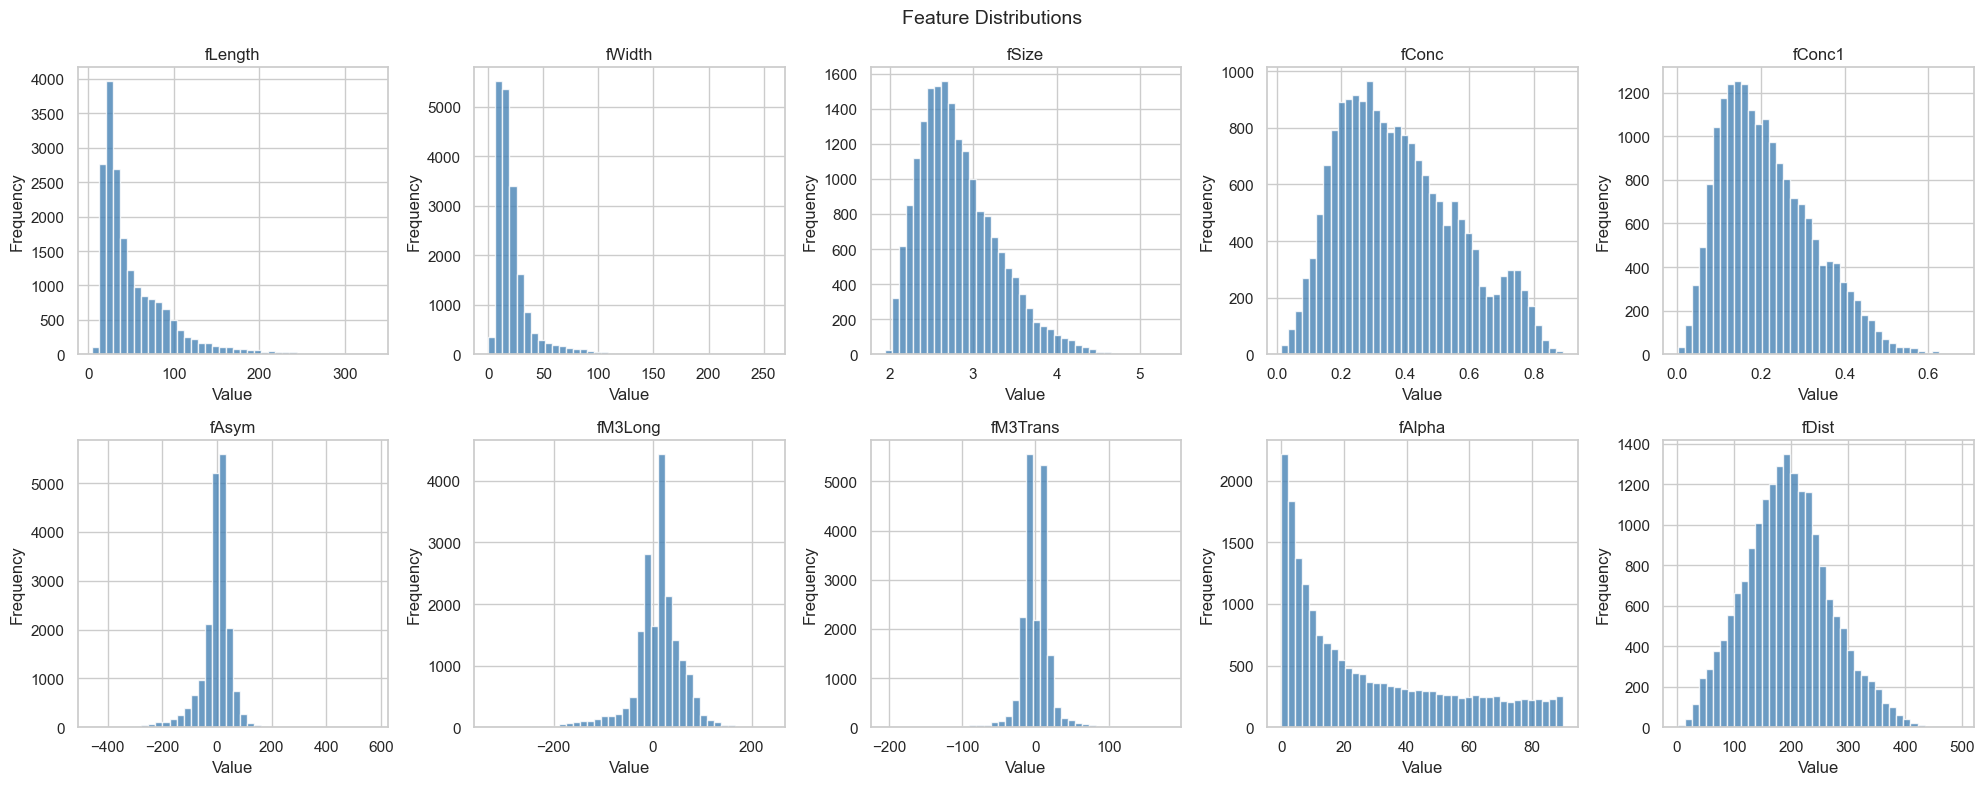

In [7]:
features = [col for col in df.columns if col != 'class']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

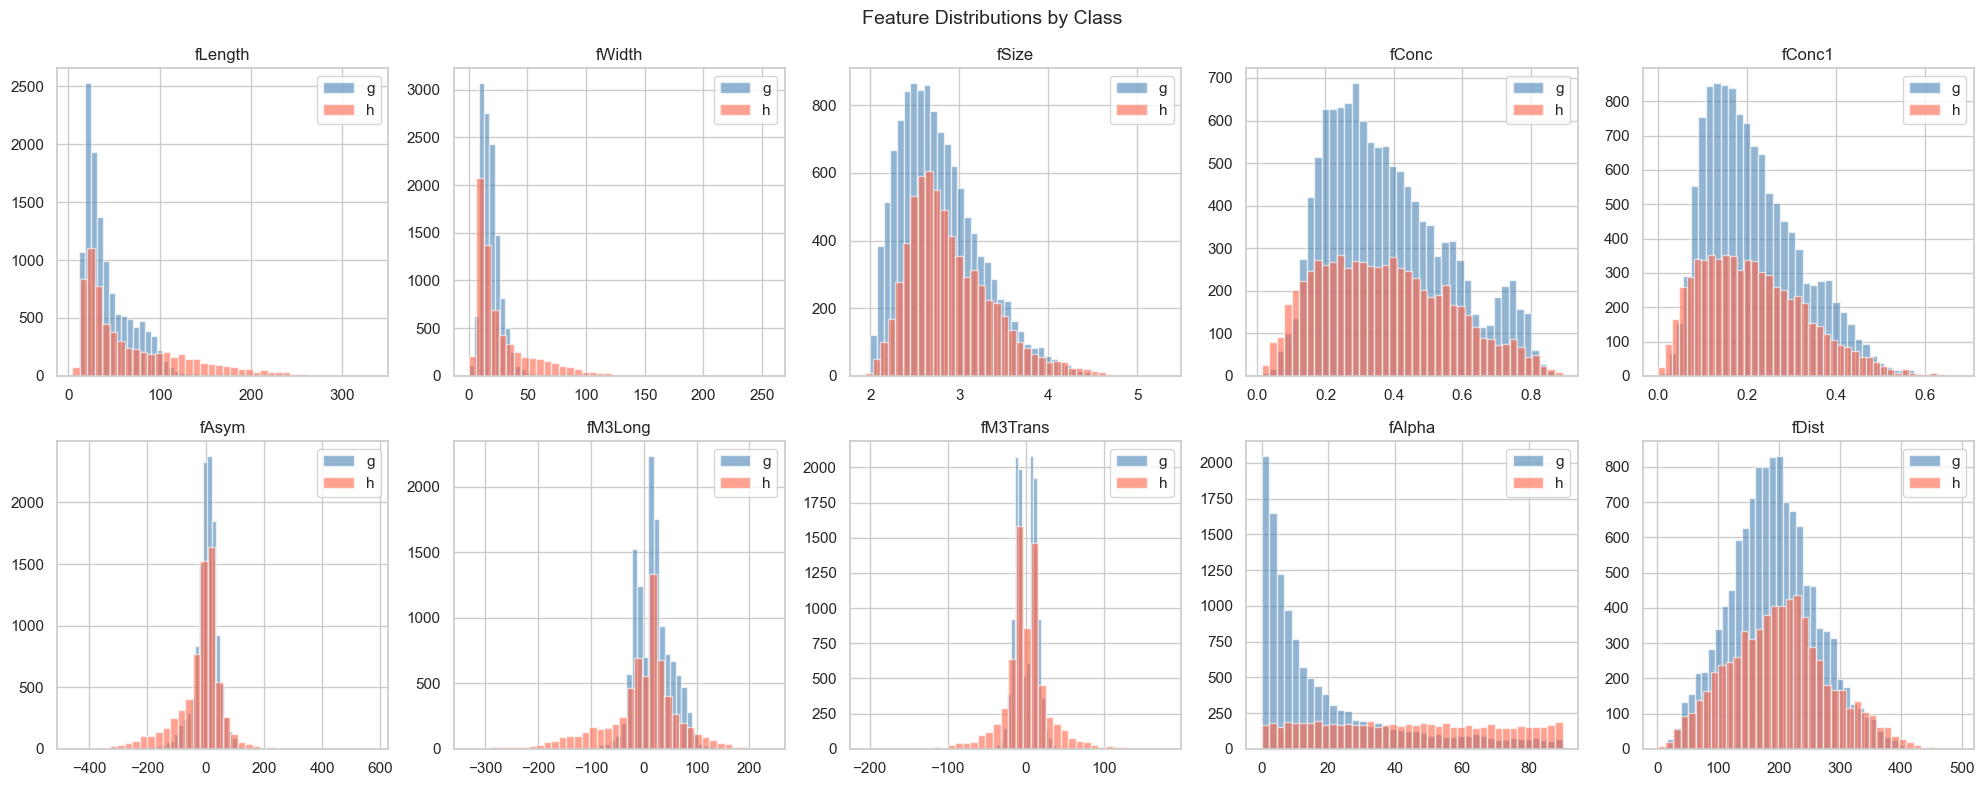

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for cls, color in zip(['g', 'h'], ['steelblue', 'tomato']):
        axes[i].hist(df[df['class'] == cls][col], bins=40,
                     alpha=0.6, label=cls, color=color)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

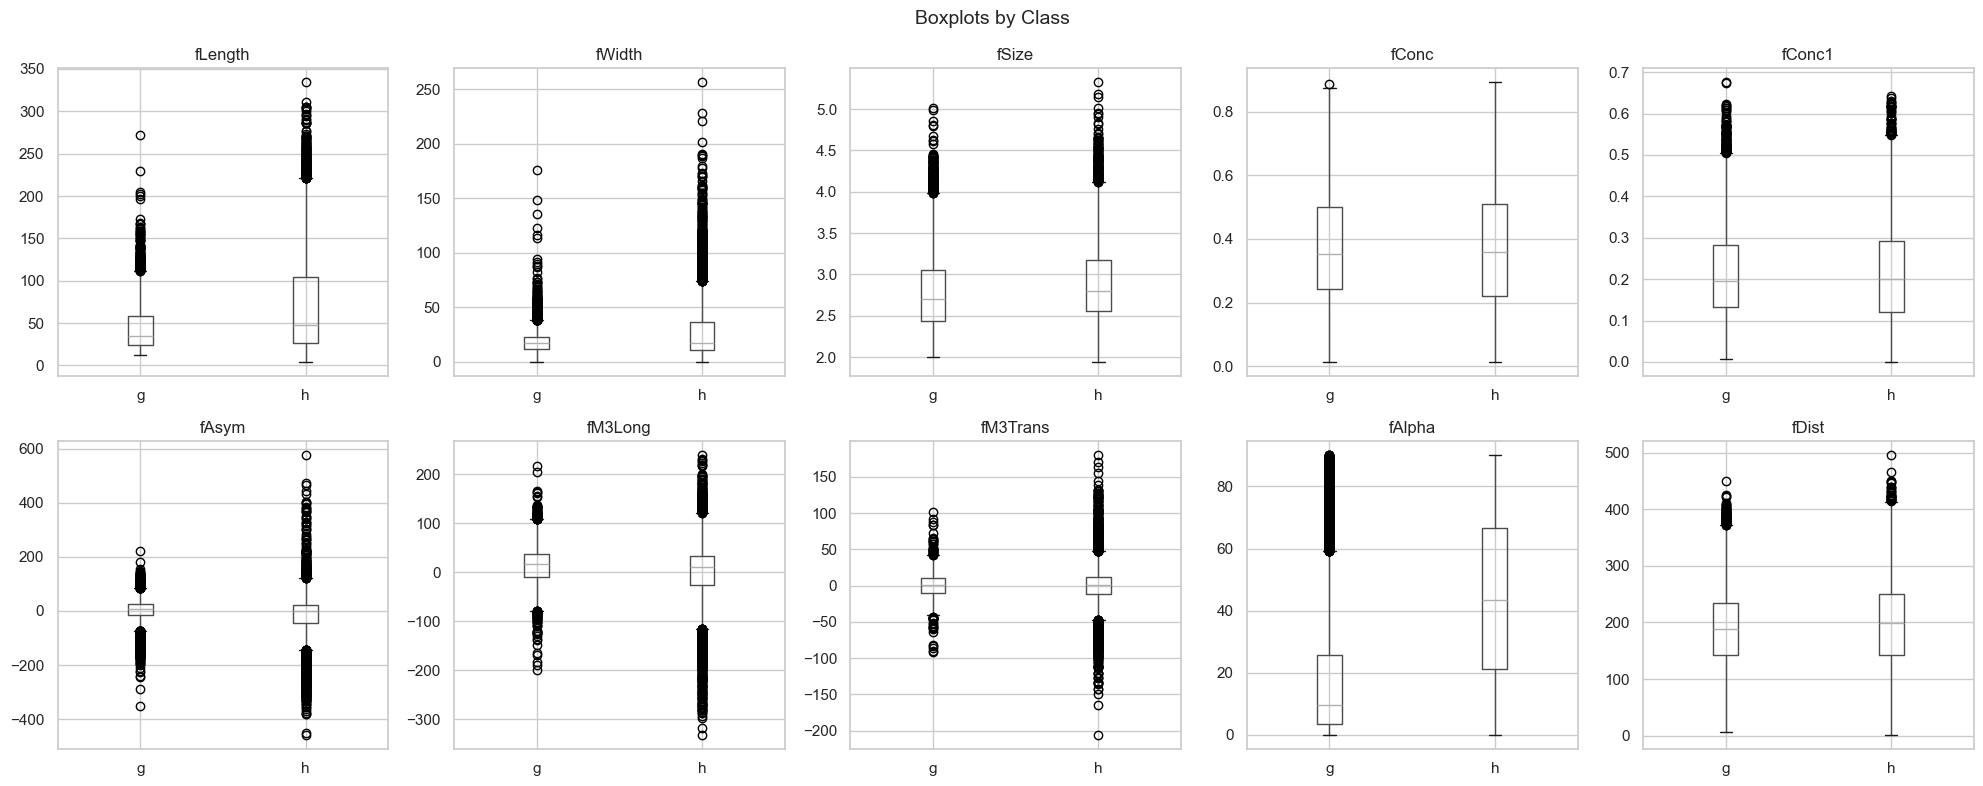

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='class', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots by Class', fontsize=14)
plt.tight_layout()
plt.show()

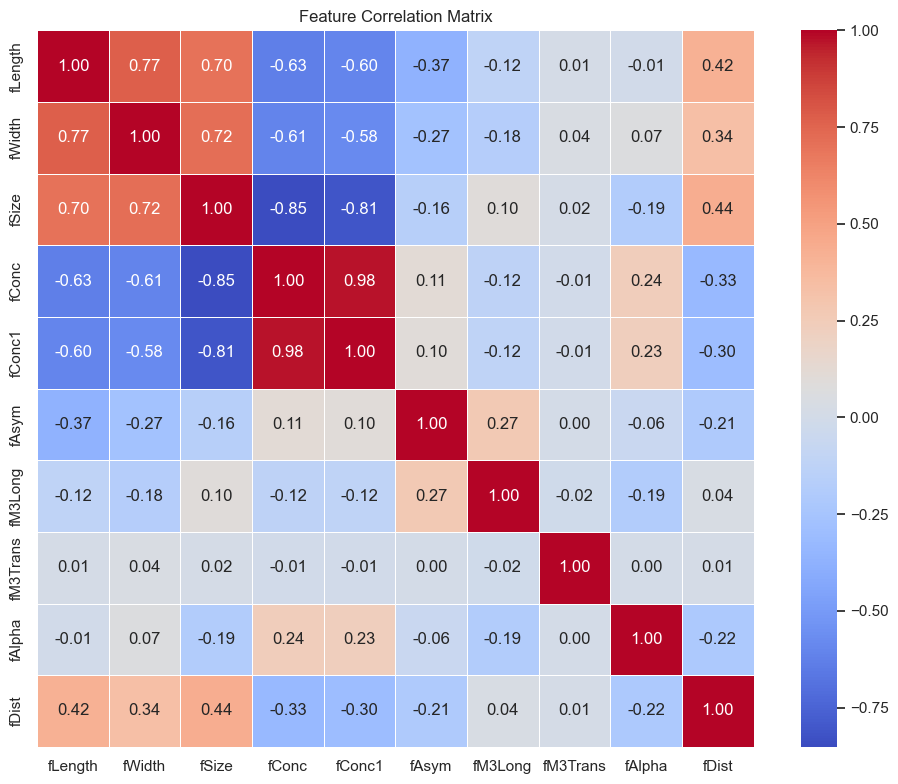

In [10]:
plt.figure(figsize=(10, 8))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [11]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="MAGIC Telescope EDA Report", explorative=True)
profile.to_file("magic_eda_report.html")
print("Report saved as magic_eda_report.html ✓")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 30.04it/s]

Report saved as magic_eda_report.html ✓


In [12]:
# Encode target
le = LabelEncoder()
df['target'] = le.fit_transform(df['class'])  # g=0, h=1
print("Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df[features]
y = df['target']

# Check for skewness and apply Yeo-Johnson
skewness = X.skew()
print("\nSkewness before transform:\n", skewness.round(3))

pt = stats.yeojohnson
# نستخدم PowerTransformer من sklearn
from sklearn.preprocessing import PowerTransformer
power_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
X_transformed = pd.DataFrame(power_transformer.fit_transform(X), columns=features)

print("\nSkewness after Yeo-Johnson:\n", X_transformed.skew().round(3))

Encoding: {'g': 0, 'h': 1}

Skewness before transform:
 fLength     2.014
fWidth      3.372
fSize       0.876
fConc       0.486
fConc1      0.686
fAsym      -1.046
fM3Long    -1.123
fM3Trans    0.120
fAlpha      0.851
fDist       0.230
dtype: float64

Skewness after Yeo-Johnson:
 fLength     0.056
fWidth      0.025
fSize       0.042
fConc       0.030
fConc1      0.052
fAsym       0.969
fM3Long     0.168
fM3Trans    0.001
fAlpha     -0.087
fDist      -0.028
dtype: float64


In [13]:
# Split: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_transformed, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)
# 0.1765 ≈ 15% of total

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Scale using StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("\nStandardScaler chosen: features have varying ranges and units.")
print("It assumes roughly Gaussian distribution after Yeo-Johnson transform.")

Train: (13313, 10), Val: (2854, 10), Test: (2853, 10)

StandardScaler chosen: features have varying ranges and units.
It assumes roughly Gaussian distribution after Yeo-Johnson transform.


In [14]:
param_random_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 3000]
}

lr = LogisticRegression(random_state=42)
rand_lr = RandomizedSearchCV(lr, param_random_lr, cv=5,
                            scoring='roc_auc', n_jobs=-1, verbose=1, n_iter=20)
rand_lr.fit(X_train_sc, y_train)

print("Best LR Params:", rand_lr.best_params_)
print("Best CV ROC-AUC:", round(rand_lr.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best LR Params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 3000, 'C': 100}
Best CV ROC-AUC: 0.8697


In [15]:
param_random_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'degree': [2, 3]
}

svm = SVC(probability=True, random_state=42)
_rand_svm = RandomizedSearchCV(svm, param_random_svm, cv=3,
                        scoring='roc_auc', n_jobs=-1, verbose=1, n_iter=30)
_rand_svm.fit(X_train_sc, y_train)

print("Best SVM Params:", _rand_svm.best_params_)
print("Best CV ROC-AUC:", round(_rand_svm.best_score_, 4))

Fitting 3 folds for each of 30 candidates, totalling 90 fits


KeyboardInterrupt: 

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    y_tr_pred  = model.predict(X_tr)
    y_val_pred = model.predict(X_v)
    y_val_prob = model.predict_proba(X_v)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train Accuracy : {accuracy_score(y_tr, y_tr_pred):.4f}")
    print(f"  Val   Accuracy : {accuracy_score(y_v, y_val_pred):.4f}")
    print(f"  Val   Precision: {precision_score(y_v, y_val_pred):.4f}")
    print(f"  Val   Recall   : {recall_score(y_v, y_val_pred):.4f}")
    print(f"  Val   F1-Score : {f1_score(y_v, y_val_pred):.4f}")
    print(f"  Val   ROC-AUC  : {roc_auc_score(y_v, y_val_prob):.4f}")

    print("\nClassification Report (Val):")
    print(classification_report(y_v, y_val_pred, target_names=['gamma', 'hadron']))

    cm = confusion_matrix(y_v, y_val_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['gamma', 'hadron'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix – {name}')
    plt.show()

evaluate_model("Logistic Regression", rand_lr.best_estimator_,
               X_train_sc, y_train, X_val_sc, y_val)

evaluate_model("SVM", _rand_svm.best_estimator_,
               X_train_sc, y_train, X_val_sc, y_val)

In [ ]:
# Test set evaluation for both
for name, model in [("Logistic Regression", rand_lr.best_estimator_),
                    ("SVM", _rand_svm.best_estimator_)]:
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    print(f"\n[TEST SET] {name}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  F1-Score : {f1_score(y_test, y_pred):.4f}")

print("""
=== Final Recommendation ===
Compare the two models on ROC-AUC (primary metric per dataset documentation).
SVM with RBF kernel typically achieves higher ROC-AUC on this dataset due to
its ability to capture non-linear boundaries between gamma and hadron events.
Select the model with higher Test ROC-AUC and lower gap between Train/Val accuracy.
""")